<a href="https://colab.research.google.com/github/bprajas/PINN-without-autograd/blob/main/PINNvsNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 1: 1-tanh-3-tanh-3-tanh-3-tanh-1-tanh-out-mse-backprop

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

w = [0.5, -1.2, 0.3]
b = [0.0, 0.2, -0.1]
w1 = [[0.2, -0.5, 0.3],
      [1.0, -0.7, 0.8],
      [0.4, 0.6, -0.9]]
b1 = [0.0, 0.2, -0.1]
w2 = [[0.9, -0.2, 0.4],
      [-0.6, 0.3, 0.7],
      [0.1, 0.5, -0.8]]
b2 = [0.05, -0.05, 0.1]
w3 = [[0.9, -0.2, 0.4],
      [-0.6, 0.3, 0.7],
      [0.1, 0.5, -0.8]]
b3 = [0.0, 0.1, -0.1]
w4 = [0.3, -0.7, 0.5]
b4 = 0.0

def forward(x, w, b, w1, b1, w2, b2, w3, b3, w4, b4):
    layerdata1=[]
    for i in range(len(w)):
        layerdata1.append(np.tanh(w[i]*x+b[i]))

    layerdata2=[]
    for j in range(len(w1)):
        store=0
        for k in range(len(layerdata1)):
            store+=w1[j][k]*layerdata1[k]
        store+=b1[j]
        layerdata2.append(np.tanh(store))

    layerdata3=[]
    for l in range(len(w2)):
        store=0
        for m in range(len(layerdata2)):
            store+=w2[l][m]*layerdata2[m]
        store+=b2[l]
        layerdata3.append(np.tanh(store))

    layerdata4=[]
    for n in range(len(w3)):
        store=0
        for o in range(len(layerdata3)):
            store+=layerdata3[o]*w3[n][o]
        store+=b3[n]
        layerdata4.append(np.tanh(store))

    output=0
    for p in range(len(w4)):
        output+=layerdata4[p]*w4[p]
    output+=b4
    return output,layerdata1,layerdata2,layerdata3,layerdata4

def train(x, y, w, b, w1, b1, w2, b2, w3, b3, w4, b4, lr=0.01):
        output, laydat1, laydat2, laydat3, laydat4 = forward(x, w, b, w1, b1, w2, b2, w3, b3, w4, b4)
        Loss=0.5*(output-y)**2
        dLout=output-y
        dLlaydat4=[dLout*w4[p]*(1-laydat4[p]**2) for p in range(len(w4))]

        dLlaydat3=[]
        for o in range(len(laydat3)):
            s=0
            for n in range(len(laydat4)):
                s+=dLlaydat4[n]*w3[n][o]
            dLlaydat3.append(s*(1-laydat3[o]**2))

        dLlaydat2=[]
        for o in range(len(laydat2)):
            s=0
            for n in range(len(laydat3)):
                s+=dLlaydat3[n]*w2[n][o]
            dLlaydat2.append(s*(1-laydat2[o]**2))

        dLlaydat1=[]
        for o in range(len(laydat1)):
            s=0
            for n in range(len(laydat2)):
                s+=dLlaydat2[n] * w1[n][o]
            dLlaydat1.append(s*(1-laydat1[o]**2))

        for i in range(len(w)):
            w[i]-=np.mean(lr*dLlaydat1[i]*x)
            b[i]-=np.mean(lr*dLlaydat1[i])

        for i in range(len(w1)):
            for j in range(len(w1[0])):
                w1[i][j]-=np.mean(lr*dLlaydat2[i]*laydat1[j])
            b1[i]-=np.mean(lr*dLlaydat2[i])

        for i in range(len(w2)):
            for j in range(len(w2[0])):
                w2[i][j]-=np.mean(lr*dLlaydat3[i]*laydat2[j])
            b2[i]-=np.mean(lr*dLlaydat3[i])

        for i in range(len(w3)):
            for j in range(len(w3[0])):
                w3[i][j]-=np.mean(lr*dLlaydat4[i]*laydat3[j])
            b3[i]-=np.mean(lr*dLlaydat4[i])

        for i in range(len(w4)):
            w4[i]-=np.mean(lr*dLout*laydat4[i])
        b4-=np.mean(lr*dLout)

        return w, b, w1, b1, w2, b2, w3, b3, w4, b4, Loss

# Experiment 1: 100 Points (Large Dataset) in [-10,10], not PINN.

SET NUMBER OF EPOCHS AND LR:


In [ ]:
EPOCHS = int(1e4)
LR = 1e-4

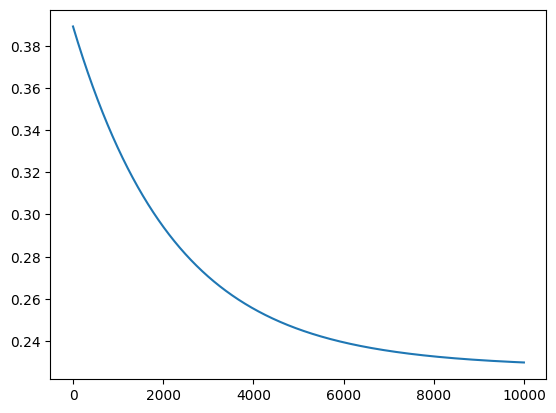

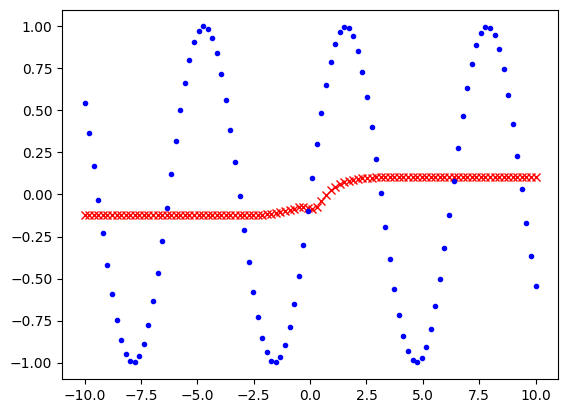

In [ ]:
x = np.linspace(-10,10,100)
y = np.sin(x)
loss_list = []
for m in range(EPOCHS):
  w, b, w1, b1, w2, b2, w3, b3, w4, b4, Loss = train(x, y, w, b, w1, b1, w2, b2, w3, b3, w4, b4, lr=LR)
  loss_list.append(np.mean(Loss))

plt.figure(1)
plt.plot(loss_list)

ypred = forward(x, w, b, w1, b1, w2, b2, w3, b3, w4, b4)

plt.figure(2)
plt.plot(x,ypred[0],'xr')
plt.plot(x,y,'.b')

# Experiment 2: 10 Points (Small Dataset) in [-10,10], not PINN.

SET NUMBER OF EPOCHS AND LR:


In [ ]:
EPOCHS = int(1e4)
LR = 1e-4

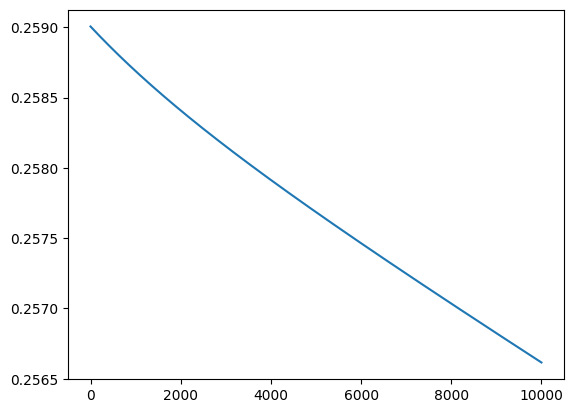

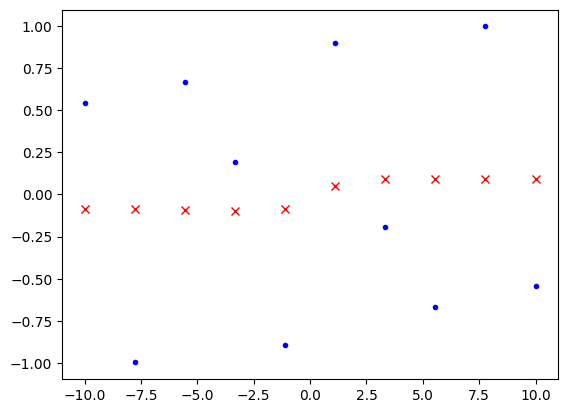

In [ ]:
x = np.linspace(-10,10,10)
y = np.sin(x)
loss_list = []
for m in range(EPOCHS):
  w, b, w1, b1, w2, b2, w3, b3, w4, b4, Loss = train(x, y, w, b, w1, b1, w2, b2, w3, b3, w4, b4, lr=LR)
  loss_list.append(np.mean(Loss))

plt.figure(1)
plt.plot(loss_list)

ypred = forward(x, w, b, w1, b1, w2, b2, w3, b3, w4, b4)

plt.figure(2)
plt.plot(x,ypred[0],'xr')
plt.plot(x,y,'.b')

# Model 2: 1-tanh-3-tanh-3-tanh-3-tanh-1-tanh-out-mse+physicsloss-backprop

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

w = [0.5, -1.2, 0.3]
b = [0.0, 0.2, -0.1]
w1 = [[0.2, -0.5, 0.3],
      [1.0, -0.7, 0.8],
      [0.4, 0.6, -0.9]]
b1 = [0.0, 0.2, -0.1]
w2 = [[0.9, -0.2, 0.4],
      [-0.6, 0.3, 0.7],
      [0.1, 0.5, -0.8]]
b2 = [0.05, -0.05, 0.1]
w3 = [[0.9, -0.2, 0.4],
      [-0.6, 0.3, 0.7],
      [0.1, 0.5, -0.8]]
b3 = [0.0, 0.1, -0.1]
w4 = [0.3, -0.7, 0.5]
b4 = 0.0

def forward(x, w, b, w1, b1, w2, b2, w3, b3, w4, b4):
    layerdata1=[]
    for i in range(len(w)):
        layerdata1.append(np.tanh(w[i]*x+b[i]))

    layerdata2=[]
    for j in range(len(w1)):
        store=0
        for k in range(len(layerdata1)):
            store+=w1[j][k]*layerdata1[k]
        store+=b1[j]
        layerdata2.append(np.tanh(store))

    layerdata3=[]
    for l in range(len(w2)):
        store=0
        for m in range(len(layerdata2)):
            store+=w2[l][m]*layerdata2[m]
        store+=b2[l]
        layerdata3.append(np.tanh(store))

    layerdata4=[]
    for n in range(len(w3)):
        store=0
        for o in range(len(layerdata3)):
            store+=layerdata3[o]*w3[n][o]
        store+=b3[n]
        layerdata4.append(np.tanh(store))

    output=0
    for p in range(len(w4)):
        output+=layerdata4[p]*w4[p]
    output+=b4
    return output,layerdata1,layerdata2,layerdata3,layerdata4

def physics_loss(x, y, w, b, w1, b1, w2, b2, w3, b3, w4, b4, eps=1e-4):
    y1,_,_,_,_ = forward(x, w, b, w1, b1, w2, b2, w3, b3, w4, b4)
    y2,_,_,_,_ = forward(x+eps, w, b, w1, b1, w2, b2, w3, b3, w4, b4)
    y3,_,_,_,_ = forward(x-eps, w, b, w1, b1, w2, b2, w3, b3, w4, b4)

    dydx = (y2-y1)/eps
    d2ydx2 = (y2 - 2*y1 + y3)/eps**2
    return d2ydx2 + y1

def train(x, y, w, b, w1, b1, w2, b2, w3, b3, w4, b4, lr, lam):
        output, laydat1, laydat2, laydat3, laydat4 = forward(x, w, b, w1, b1, w2, b2, w3, b3, w4, b4)
        lossmse=0.5*(output-y)**2
        lossphysics=physics_loss(x, y, w, b, w1, b1, w2, b2, w3, b3, w4, b4, eps=1e-4)
        lossphysics1 = 0.5*(lossphysics**2)
        Loss = (1-lam)*lossmse+lam*lossphysics1
        dLout=(1-lam)*(output-y)+lam*lossphysics
        dLlaydat4=[dLout*w4[p]*(1-laydat4[p]**2) for p in range(len(w4))]

        dLlaydat3=[]
        for o in range(len(laydat3)):
            s=0
            for n in range(len(laydat4)):
                s+=dLlaydat4[n]*w3[n][o]
            dLlaydat3.append(s*(1-laydat3[o]**2))

        dLlaydat2=[]
        for o in range(len(laydat2)):
            s=0
            for n in range(len(laydat3)):
                s+=dLlaydat3[n]*w2[n][o]
            dLlaydat2.append(s*(1-laydat2[o]**2))

        dLlaydat1=[]
        for o in range(len(laydat1)):
            s=0
            for n in range(len(laydat2)):
                s+=dLlaydat2[n] * w1[n][o]
            dLlaydat1.append(s*(1-laydat1[o]**2))

        for i in range(len(w)):
            w[i]-=np.mean(lr*dLlaydat1[i]*x)
            b[i]-=np.mean(lr*dLlaydat1[i])

        for i in range(len(w1)):
            for j in range(len(w1[0])):
                w1[i][j]-=np.mean(lr*dLlaydat2[i]*laydat1[j])
            b1[i]-=np.mean(lr*dLlaydat2[i])

        for i in range(len(w2)):
            for j in range(len(w2[0])):
                w2[i][j]-=np.mean(lr*dLlaydat3[i]*laydat2[j])
            b2[i]-=np.mean(lr*dLlaydat3[i])

        for i in range(len(w3)):
            for j in range(len(w3[0])):
                w3[i][j]-=np.mean(lr*dLlaydat4[i]*laydat3[j])
            b3[i]-=np.mean(lr*dLlaydat4[i])

        for i in range(len(w4)):
            w4[i]-=np.mean(lr*dLout*laydat4[i])
        b4-=np.mean(lr*dLout)

        return w, b, w1, b1, w2, b2, w3, b3, w4, b4, Loss

# Experiment 3: 10 Points (Small Dataset) in [-10,10], PINN.

SET NUMBER OF EPOCHS, PHYSICS LOSS COEFFICIENT LAM AND LR:


In [ ]:
EPOCHS = int(1e5)
LR = 1e-4
LAM = 0.55

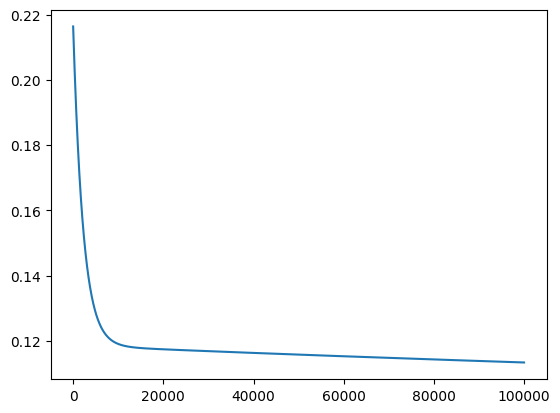

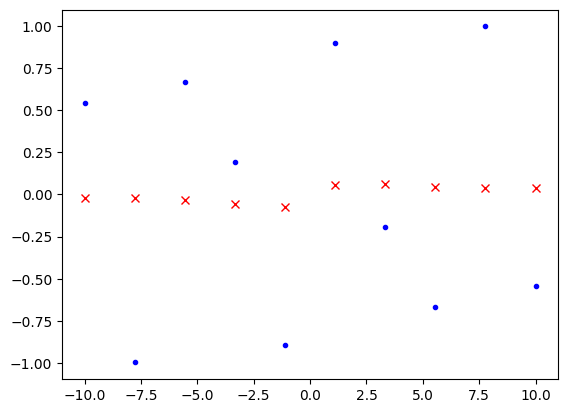

In [ ]:
x = np.linspace(-10,10,10)
y = np.sin(x)
loss_list = []
for m in range(EPOCHS):
  w, b, w1, b1, w2, b2, w3, b3, w4, b4, Loss = train(x, y, w, b, w1, b1, w2, b2, w3, b3, w4, b4, LR, LAM)
  loss_list.append(np.mean(Loss))

plt.figure(1)
plt.plot(loss_list)

ypred = forward(x, w, b, w1, b1, w2, b2, w3, b3, w4, b4)

plt.figure(2)
plt.plot(x,ypred[0],'xr')
plt.plot(x,y,'.b')